# 6. Baseline Modelling

This notebook implements **baseline models** for revenue forecasting at the Business Subsegment level, organized in two main parts:

- **6.1 Time Series Models** — Classical TS approaches that operate on the raw Revenue/Orders series per subsegment.
- **6.2 Machine Learning Models** — ML models leveraging the full set of engineered features from Feature Selection.

---

**Target**: Revenue cons. (anon) — Orders used as leading indicator (not a target).  
**Granularity**: One model per TGL Business Subsegment (134 series).  
**Validation**: Train on periods 1–36, validate on 37–42 (6-period horizon).  
**Test**: Periods 43–48 (all targets NaN).  
**Metrics**: RMSE, MAE, wMAPE (weighted MAPE — robust to near-zero revenue subsegments), R² (coefficient of determination).  

**6.1 Time Series Models**: Naïve / Seasonal Naïve / Moving Average → SARIMA → VAR → Prophet → Chronos (zero-shot)  
**6.2 ML Models**: 

> **Note**: TS models (6.1) operate on the raw Revenue/Orders series per subsegment. Categorical columns serve as **grouping keys**. ML models (6.2) leverage the 100 engineered features from Feature Selection.

In [1]:
import os, sys
import time

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb


# Register DLL directories BEFORE any heavy imports (fixes WinError 127 with torch on Windows)
if os.name == 'nt':
    _lib_bin = os.path.join(sys.prefix, 'Library', 'bin')
    if os.path.isdir(_lib_bin):
        os.environ['PATH'] = _lib_bin + os.pathsep + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            try: os.add_dll_directory(_lib_bin)
            except OSError: pass
    import importlib.util as _ilu
    _spec = _ilu.find_spec('torch')
    if _spec and _spec.origin:
        for _subdir in ('lib', 'bin'):
            _d = os.path.join(os.path.dirname(_spec.origin), _subdir)
            if os.path.isdir(_d):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
                if hasattr(os, 'add_dll_directory'):
                    try: os.add_dll_directory(_d)
                    except OSError: pass

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Sklearn — preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

# Baseline models
from src.code.baseline_models import *

%load_ext autoreload
%autoreload 2


print('All imports successful.')

All imports successful.


## 6.0 Data Loading

In [2]:
data_dir = '../data/features'

train_full = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fs.parquet'))
test_df    = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fs.parquet'))

TARGET     = 'Revenue cons. (anon)'
ORDERS_COL = 'Orders cons. (anon)'
PERIOD_COL = 'Anon Period'
SUBSEG_COL = 'TGL Business Subsegment'
ID_COLS    = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']

print(f'Training:   {train_full.shape}  |  Periods: {train_full[PERIOD_COL].min()}–{train_full[PERIOD_COL].max()}')
print(f'Test:       {test_df.shape}  |  Periods: {test_df[PERIOD_COL].min()}–{test_df[PERIOD_COL].max()}')
print(f'Unique subsegments: {train_full[SUBSEG_COL].nunique()}')

Training:   (4237, 106)  |  Periods: 1–42
Test:       (715, 106)  |  Periods: 43–48
Unique subsegments: 134


## 6.0.1 Internal Validation Split

The test set (periods 43–48) has all targets as NaN. We create an internal temporal split from training data:
- **Train**: periods 1–36
- **Validation**: periods 37–42 (mimics the 6-period test horizon)

In [3]:
VAL_CUTOFF = 36
HORIZON    = 6

train_df = train_full[train_full[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df   = train_full[train_full[PERIOD_COL] > VAL_CUTOFF].copy()

subsegments = get_valid_subsegments(train_df, TARGET)

# Series length diagnostics
lengths = [len(get_subsegment_series(train_df, s, PERIOD_COL, TARGET).dropna()) for s in subsegments]

print(f'Internal train: {train_df.shape} — periods {train_df[PERIOD_COL].min()}–{train_df[PERIOD_COL].max()}')
print(f'Internal val:   {val_df.shape} — periods {val_df[PERIOD_COL].min()}–{val_df[PERIOD_COL].max()}')
print(f'\nSubsegments with revenue data: {len(subsegments)}')
print(f'Series lengths — min: {min(lengths)}, median: {np.median(lengths):.0f}, max: {max(lengths)}')
print(f'Series with ≥ 24 points (seasonal SARIMA): {sum(l >= 24 for l in lengths)}')
print(f'Series with < 12 points: {sum(l < 12 for l in lengths)}')

Internal train: (3524, 106) — periods 1–36
Internal val:   (713, 106) — periods 37–42

Subsegments with revenue data: 117
Series lengths — min: 2, median: 36, max: 36
Series with ≥ 24 points (seasonal SARIMA): 93
Series with < 12 points: 12


---

## 6.1 Time Series Models

### 6.1.1 Naïve Baselines

Minimum performance bar — any model must beat these.

| Baseline | Logic |
|----------|-------|
| **Naïve** | $\\hat{y}_t = y_{t-1}$ |
| **Seasonal Naïve** | $\\hat{y}_t = y_{t-12}$ |
| **Moving Average** | $\\hat{y}_t = \\text{mean}(y_{t-1}, ..., y_{t-k})$ |

In [4]:
naive_all = run_naive_baselines(subsegments, train_df, val_df, PERIOD_COL, TARGET)

baseline_metrics = []
for name, res in naive_all.items():
    metrics = evaluate_model(res, val_df, PERIOD_COL, TARGET, name)
    baseline_metrics.append(metrics)
    print(f"{name:20s} — RMSE: {metrics['RMSE']:>14,.0f} | MAE: {metrics['MAE']:>14,.0f} | wMAPE: {metrics['wMAPE']:.1f}%")

print(f'\nBaselines computed for {len(naive_all["Naïve"])} subsegments.')

Naïve                — RMSE:     20,881,478 | MAE:      9,968,088 | wMAPE: 26.0%
Seasonal Naïve       — RMSE:     12,800,528 | MAE:      5,346,114 | wMAPE: 14.0%
Moving Avg (3)       — RMSE:     11,403,219 | MAE:      5,406,896 | wMAPE: 14.1%
Moving Avg (6)       — RMSE:      9,709,532 | MAE:      4,588,482 | wMAPE: 12.0%

Baselines computed for 110 subsegments.


---

### 6.1.2 SARIMA

SARIMA models a single univariate series per subsegment. Uses pmdarima.auto_arima for automatic (p,d,q)×(P,D,Q,m) selection. Seasonal period m=12 if ≥24 data points.

\\phi(B)\\Phi(B^{12})(1-B)^d(1-B^{12})^D y_t = \\theta(B)\\Theta(B^{12})\\epsilon_t

In [5]:
sarima_results, sarima_errors = run_sarima(subsegments, train_df, val_df, PERIOD_COL, TARGET)

sarima_metrics = evaluate_model(sarima_results, val_df, PERIOD_COL, TARGET, 'SARIMA')
print(f"SARIMA — RMSE: {sarima_metrics['RMSE']:,.0f} | MAE: {sarima_metrics['MAE']:,.0f} | wMAPE: {sarima_metrics['wMAPE']:.1f}% | R²: {sarima_metrics['R2']:.4f}")

  SARIMA progress: 25/117 subsegments...
  SARIMA progress: 50/117 subsegments...
  SARIMA progress: 75/117 subsegments...
  SARIMA progress: 100/117 subsegments...

SARIMA fitted for 105 subsegments. Errors: 2
SARIMA — RMSE: 14,774,150 | MAE: 5,923,012 | wMAPE: 15.3% | R²: 0.9538


---

### 6.1.3 VAR — Vector Autoregression

VAR captures the interaction between Revenue and Orders (leading indicator).

\\mathbf{y}_t = \\mathbf{c} + \\sum_{i=1}^{p} \\mathbf{A}_i \\mathbf{y}_{t-i} + \\mathbf{u}_t \\quad \\text{where } \\mathbf{y}_t = [\\text{Revenue}_t, \\text{Orders}_t]^\\top

In [6]:
var_results, var_errors = run_var(subsegments, train_df, val_df, PERIOD_COL, TARGET, ORDERS_COL)

var_metrics = evaluate_model(var_results, val_df, PERIOD_COL, TARGET, 'VAR')
print(f"VAR — RMSE: {var_metrics['RMSE']:,.0f} | MAE: {var_metrics['MAE']:,.0f} | wMAPE: {var_metrics['wMAPE']:.1f}% | R²: {var_metrics['R2']:.4f}")

  VAR progress: 25/117 subsegments...
  VAR progress: 50/117 subsegments...
  VAR progress: 75/117 subsegments...
  VAR progress: 100/117 subsegments...

VAR fitted for 89 subsegments. Errors: 11
VAR — RMSE: 16,254,747 | MAE: 7,348,745 | wMAPE: 16.2% | R²: 0.9493


---

### 6.1.4 Facebook Prophet

Auto-decomposes series into trend + seasonality. changepoint_prior_scale=0.01 to reduce overfitting (professor's advice).

y(t) = g(t) + s(t) + h(t) + \\epsilon_t

In [7]:
prophet_results, prophet_errors = run_prophet(subsegments, train_df, val_df, PERIOD_COL, TARGET)

prophet_metrics = evaluate_model(prophet_results, val_df, PERIOD_COL, TARGET, 'Prophet')
print(f"Prophet — RMSE: {prophet_metrics['RMSE']:,.0f} | MAE: {prophet_metrics['MAE']:,.0f} | wMAPE: {prophet_metrics['wMAPE']:.1f}% | R²: {prophet_metrics['R2']:.4f}")

  Prophet progress: 25/117 subsegments...
  Prophet progress: 50/117 subsegments...
  Prophet progress: 75/117 subsegments...
  Prophet progress: 100/117 subsegments...

Prophet fitted for 107 subsegments. Errors: 0
Prophet — RMSE: 12,154,381 | MAE: 5,770,040 | wMAPE: 14.9% | R²: 0.9683


---

### 6.1.5 Amazon Chronos (Zero-Shot Transformer)

Foundation model pre-trained on millions of time series — **no training needed**. We feed each subsegment's history and get forecasts. Uses mazon/chronos-t5-small.

> ⚠️ Requires PyTorch. If torch has DLL issues in your conda environment, this section will be skipped gracefully.

In [8]:
chronos_results, chronos_errors = run_chronos(subsegments, train_df, val_df, PERIOD_COL, TARGET)

if chronos_results:
    chronos_metrics = evaluate_model(chronos_results, val_df, PERIOD_COL, TARGET, 'Chronos (Zero-Shot)')
    print(f"Chronos — RMSE: {chronos_metrics['RMSE']:,.0f} | MAE: {chronos_metrics['MAE']:,.0f} | wMAPE: {chronos_metrics['wMAPE']:.1f}% | R²: {chronos_metrics['R2']:.4f}")
else:
    chronos_metrics = {'Model': 'Chronos (Zero-Shot)', 'RMSE': np.nan, 'MAE': np.nan, 'wMAPE': np.nan, 'R2': np.nan}
    print('Chronos skipped — see errors above.')

⚠️ Chronos unavailable: No module named 'torch'
  Skipping Chronos — install torch + chronos-forecasting to enable.
Chronos skipped — see errors above.


---

### 6.1.6 ETS — Exponential Smoothing (Holt-Winters)

ETS decomposes each series into **Error + Trend + Seasonality** with exponentially decaying weights.
More flexible than Moving Average because it automatically learns the weight of recent periods.

$$y_t = \ell_{t-1} + b_{t-1} + s_{t-m} + \epsilon_t$$

where $\ell$ is the level, $b$ the trend, and $s$ the seasonal component with period $m=12$.

In [9]:
ets_results, ets_errors = run_ets(subsegments, train_df, val_df, PERIOD_COL, TARGET)

ets_metrics = evaluate_model(ets_results, val_df, PERIOD_COL, TARGET, 'ETS (Holt-Winters)')
print(f"ETS — RMSE: {ets_metrics['RMSE']:,.0f} | MAE: {ets_metrics['MAE']:,.0f} | wMAPE: {ets_metrics['wMAPE']:.1f}% | R²: {ets_metrics['R2']:.4f}")    

  ETS progress: 25/117 subsegments...
  ETS progress: 50/117 subsegments...
  ETS progress: 75/117 subsegments...
  ETS progress: 100/117 subsegments...
  ETS done. Errors: 0/117
ETS — RMSE: 14,377,822 | MAE: 6,289,845 | wMAPE: 16.4% | R²: 0.9553


---

### 6.1.6 Time Series Model Comparison

In [10]:
all_metrics = baseline_metrics + [sarima_metrics, var_metrics, ets_metrics, prophet_metrics, chronos_metrics]
comparison_df = pd.DataFrame(all_metrics)[['Model', 'RMSE', 'MAE', 'wMAPE', 'R2']]
comparison_df = comparison_df.sort_values('RMSE').reset_index(drop=True)

print('=' * 72)
print('MODEL COMPARISON — Validation (Periods 37–42)')
print('=' * 72)

comparison_df.style.format(
    {'RMSE': '{:,.0f}', 'MAE': '{:,.0f}', 'wMAPE': '{:.1f}%', 'R2': '{:.4f}'}
).highlight_min(subset=['RMSE', 'MAE', 'wMAPE'], color='green').highlight_max(subset=['R2'], color='green')

MODEL COMPARISON — Validation (Periods 37–42)


,Model,RMSE,MAE,wMAPE,R2
0,Moving Avg (6),"9,709,532","4,588,482",12.0%,0.9796
1,Moving Avg (3),"11,403,219","5,406,896",14.1%,0.9719
2,Prophet,"12,154,381","5,770,040",14.9%,0.9683
3,Seasonal Naïve,"12,800,528","5,346,114",14.0%,0.9645
4,ETS (Holt-Winters),"14,377,822","6,289,845",16.4%,0.9553
5,SARIMA,"14,774,150","5,923,012",15.3%,0.9538
6,VAR,"16,254,747","7,348,745",16.2%,0.9493
7,Naïve,"20,881,478","9,968,088",26.0%,0.9056
8,Chronos (Zero-Shot),nan,nan,nan%,nan


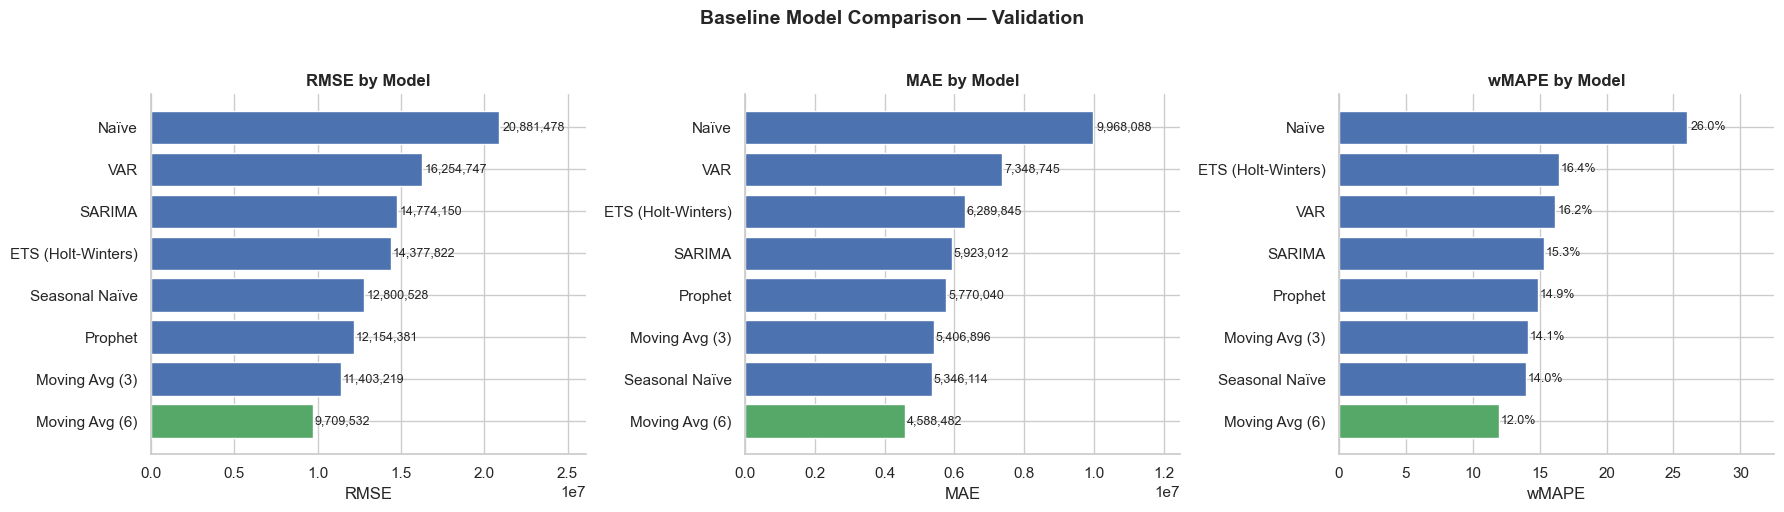

In [11]:
plot_model_comparison(comparison_df)

#### Actual vs Predicted — Representative Subsegments

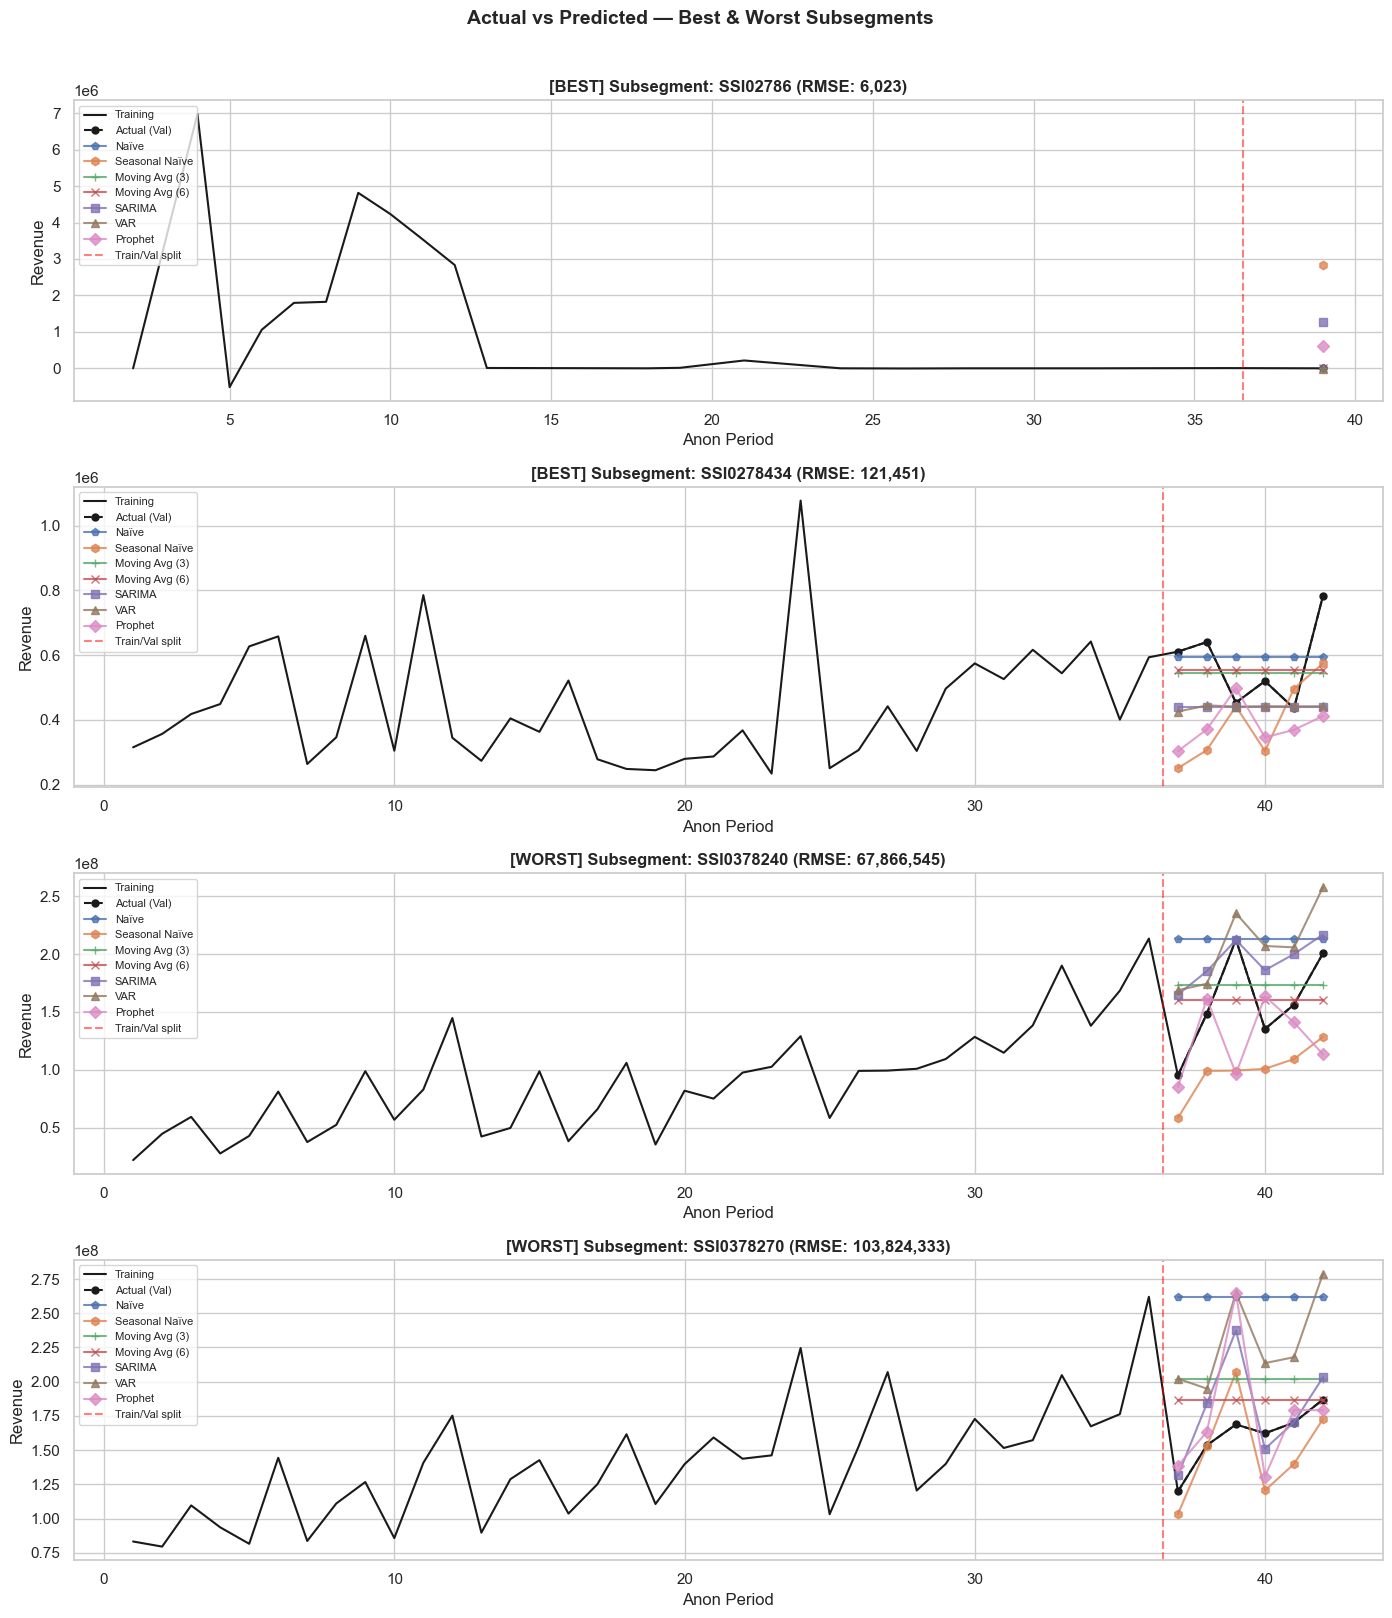

In [12]:
# Combine all model results for the comparison plot
all_results = {}
all_results.update(naive_all)  # Naïve, Seasonal Naïve, Moving Avg (3), Moving Avg (6)
all_results['SARIMA'] = sarima_results
all_results['VAR'] = var_results
all_results['Prophet'] = prophet_results
if chronos_results:
    all_results['Chronos (Zero-Shot)'] = chronos_results

plot_actual_vs_predicted(all_results, train_full, val_df, PERIOD_COL, TARGET, VAL_CUTOFF)

---

### 6.1.7 Baseline Summary

- **Naïve baselines** establish the minimum performance bar
- **SARIMA** models univariate seasonal patterns per subsegment
- **VAR** captures Revenue–Orders lead-lag dynamics (bivariate)
- **Prophet** auto-decomposes trend + seasonality
- **Chronos** provides zero-shot forecasting from a pre-trained transformer

> ℹ️ These baselines are **univariate/bivariate** — they do not use the full 100-feature set. The next section prepares the pipeline for ML models that leverage all features.

In [13]:
print('\n' + '=' * 72)
print('FINAL BASELINE RESULTS')
print('=' * 72)
print(comparison_df.to_string(index=False))
print(f'\nBest model by RMSE: {comparison_df.iloc[0]["Model"]}')


FINAL BASELINE RESULTS
              Model         RMSE          MAE     wMAPE       R2
     Moving Avg (6) 9.709532e+06 4.588482e+06 11.973316 0.979592
     Moving Avg (3) 1.140322e+07 5.406896e+06 14.108909 0.971852
            Prophet 1.215438e+07 5.770040e+06 14.868039 0.968296
     Seasonal Naïve 1.280053e+07 5.346114e+06 13.950303 0.964531
 ETS (Holt-Winters) 1.437782e+07 6.289845e+06 16.412902 0.955251
             SARIMA 1.477415e+07 5.923012e+06 15.301587 0.953799
                VAR 1.625475e+07 7.348745e+06 16.162206 0.949301
              Naïve 2.088148e+07 9.968088e+06 26.011013 0.905611
Chronos (Zero-Shot)          NaN          NaN       NaN      NaN

Best model by RMSE: Moving Avg (6)


---

## 6.2 Machine Learning Models

This section benchmarks ML models for revenue forecasting using **recursive multi-step prediction** to avoid data leakage.

**Key design decisions:**
- **Orders/ASP features dropped** — the test set (periods 43–48) has neither Orders nor Revenue, so any feature derived from these is unusable at inference time.
- **Recursive forecasting** — lag features are recomputed at each prediction step using only past actuals + previous predictions. Direct prediction with pre-computed lags would leak future Revenue values through the lag columns.
- **Two hierarchy levels** — Subsegment (bottom-up, ~100 series) and Segment (middle-out, ~24 series).

---
### 6.2.0 Imports & Configuration

In [14]:
from src.code.functions_models import *

# Column aliases (from defaults in functions_models.py)
TARGET     = DEFAULT_TARGET
ORDERS_COL = DEFAULT_ORDERS_COL
PERIOD_COL = DEFAULT_PERIOD_COL
SUBSEG_COL = DEFAULT_SUBSEG_COL
SEG_COL    = DEFAULT_SEG_COL
BU_COL     = DEFAULT_BU_COL

VAL_CUTOFF = 36   # Train: periods 1-36, Validation: periods 37-42
HORIZON    = 6    # 6-period forecast horizon (matches test set)

print(f'Train:      periods 1-{VAL_CUTOFF}')
print(f'Validation: periods {VAL_CUTOFF+1}-{VAL_CUTOFF+HORIZON}')
print(f'Test:       periods 43-48 (targets unknown)')

Train:      periods 1-36
Validation: periods 37-42
Test:       periods 43-48 (targets unknown)


---
### 6.2.1 Feature Preparation

Prepare subsegment-level features:
- Drop raw targets (Revenue, Orders) and period column
- Drop all Orders/ASP-derived features (unavailable at test time)
- Keep categorical hierarchy columns for tree-based models
- No scaling/imputation here (handled per-model in the training pipeline)

In [15]:
# Prepare subsegment-level data
X_train, y_train, X_val, y_val, feature_cols, cat_cols = prepare_subsegment_data(
    df=train_full,
    val_cutoff=VAL_CUTOFF
)

print(f'Train shape: {X_train.shape}')
print(f'Val shape:   {X_val.shape}')
print(f'Features:    {len(feature_cols)} (was ~103 before dropping Orders/ASP)')
print(f'Categoricals: {cat_cols}')

Train shape: (3524, 54)
Val shape:   (713, 54)
Features:    54 (was ~103 before dropping Orders/ASP)
Categoricals: ['TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']


---
### 6.2.2 Leakage Diagnostic

Every feature falls into one of these buckets:
- **Recomputed** — Revenue-based lags/rolling features that will be recomputed recursively at each forecast step
- **Static** — macro/temporal features that don't depend on the target (safe as-is)
- **Identity** — categorical hierarchy columns (safe)
- **Orders/ASP** — should have been dropped already (alert if present)
- **Unknown** — requires manual verification

In [16]:
coverage = diagnose_feature_coverage(feature_cols)

FEATURE COVERAGE DIAGNOSTIC
  Recomputed (leak-free) :  39
  Static (safe as-is)    :  12
  Identity (ID columns)  :   3
  UNKNOWN (check these!) :   0
------------------------------------------------------------

All features accounted for. Pipeline is clean.


---
### 6.2.3 Recursive Forecasting Engine

**Why recursive instead of direct?**

The pre-computed lag features in the parquet files use actual Revenue for ALL periods, including validation. For example, `Rev_Lag_1` at period 38 contains the actual Revenue from period 37 — which is a validation target. This is **data leakage**.

**Recursive approach:**
1. Train the model on periods 1–36 (lags computed from actuals — safe)
2. Predict period 37 → store predictions as "pseudo-actuals"
3. Recompute lags for period 38 using actuals (≤36) + prediction (37)
4. Predict period 38 → store, recompute for 39, and so on...

This ensures the model never sees future Revenue values during evaluation.

---
### 6.2.4 Model Definitions

| Model             | Type          | Handles NaN | Handles Categoricals | Notes                          |
|:------------------|:--------------|:-----------:|:--------------------:|:-------------------------------|
| LightGBM          | Boosting      | Yes         | Yes (native)         | Fast, strong baseline          |
| XGBoost           | Boosting      | Yes         | Yes (enable_categorical) | Robust alternative         |
| CatBoost          | Boosting      | Yes         | Yes (ordered encoding) | Good with categoricals       |
| Ridge             | Linear (L2)   | No          | No (dropped)         | Drops cats, numeric only       |
| Lasso             | Linear (L1)   | No          | No (dropped)         | Feature selection via L1       |
| ElasticNet        | Linear (L1+L2)| No          | No (dropped)         | Best of Ridge + Lasso          |
| Random Forest     | Bagging       | No          | No (dropped)         | Ensemble sanity check          |
| Gradient Boosting | Boosting      | No          | No (dropped)         | sklearn exact-split boosting   |

> **Note:** Linear models and sklearn tree models drop categorical columns entirely because integer-coding them as continuous features produces nonsensical results for regression.

In [17]:
models = get_models(cat_cols, feature_cols)
print(f'{len(models)} models loaded:')
for name, (mdl, needs_pp) in models.items():
    print(f'  {name:20s} | preprocessing: {needs_pp}')

7 models loaded:
  LightGBM             | preprocessing: False
  XGBoost              | preprocessing: False
  Ridge                | preprocessing: True
  Lasso                | preprocessing: True
  ElasticNet           | preprocessing: True
  Random Forest        | preprocessing: True
  Gradient Boosting    | preprocessing: True


---
### 6.2.5 Subsegment-Level Benchmarking (Recursive Forecast)

Run all models with recursive forecasting on validation periods 37–42.
Each model is trained on periods 1–36 and evaluated step-by-step.

In [18]:
print('=' * 72)
print('SUBSEGMENT-LEVEL BENCHMARKING (Recursive Forecast)')
print('=' * 72)


group_cols_sub = [DEFAULT_BU_COL, DEFAULT_SEG_COL, DEFAULT_SUBSEG_COL]
# Create Target_Delta for Subsegments
train_full = train_full.sort_values(by=group_cols_sub + [PERIOD_COL])
train_full['Target_Delta'] = train_full.groupby(group_cols_sub)[TARGET].diff().fillna(0)

sparsity_sub = train_full.groupby(group_cols_sub)[TARGET].transform(lambda x: (x > 0).mean())
train_full = train_full[sparsity_sub > 0.30].copy()

results_subseg, forecasts_subseg, fitted_subseg = run_recursive_benchmark(
    train_full    = train_full,
    val_cutoff    = VAL_CUTOFF,
    feature_cols  = feature_cols,
    cat_cols      = cat_cols,
    level_name    = 'Subsegment',
    group_cols    = group_cols_sub,
    target        = 'Target_Delta',
    absolute_target = TARGET,
    predicts_delta  = True
)

results_subseg_df = pd.DataFrame(results_subseg).sort_values('RMSE')
results_subseg_df

SUBSEGMENT-LEVEL BENCHMARKING (Recursive Forecast)
  LightGBM @ Subsegment ... Val RMSE:     13,847,374 | Train R²:  0.9240 | 2.1s
  XGBoost @ Subsegment ... Val RMSE:     25,332,555 | Train R²:  0.9359 | 1.9s
  Ridge @ Subsegment ... Val RMSE:  1,977,049,782 | Train R²:  0.5772 | 1.6s
  Lasso @ Subsegment ... Val RMSE:  1,977,065,405 | Train R²:  0.5799 | 3.8s
  ElasticNet @ Subsegment ... Val RMSE:  1,977,146,095 | Train R²:  0.5261 | 3.4s
  Random Forest @ Subsegment ... Val RMSE:     12,920,387 | Train R²:  0.6658 | 3.0s
  Gradient Boosting @ Subsegment ... Val RMSE:     25,402,657 | Train R²:  0.7912 | 4.4s


,Model,Level,RMSE,MAE,wMAPE,R2,N_samples,Time (s),Train R2
5,Random Forest,Subsegment,1.292039e+07,7.235794e+06,19.815926,0.962516,666,3.0,0.665774
0,LightGBM,Subsegment,1.384737e+07,8.934442e+06,24.467838,0.956944,666,2.1,0.923965
1,XGBoost,Subsegment,2.533256e+07,2.224722e+07,60.926164,0.855903,666,1.9,0.935876
6,Gradient Boosting,Subsegment,2.540266e+07,2.127892e+07,58.274388,0.855104,666,4.4,0.791206
2,Ridge,Subsegment,1.977050e+09,1.952122e+09,5346.075180,-876.672866,666,1.6,0.577215
3,Lasso,Subsegment,1.977065e+09,1.952137e+09,5346.115907,-876.686737,666,3.8,0.579919
4,ElasticNet,Subsegment,1.977146e+09,1.952192e+09,5346.267476,-876.758381,666,3.4,0.526147


---
### 6.2.6 Segment-Level Benchmarking

Aggregate subsegment data to segment level (~24 series), re-engineer lag features at segment granularity, and benchmark the same models.

**Important:** `build_segment_level_data()` computes lags from the full dataset. This means validation-period lags contain future information — which is exactly why we use **recursive forecasting** to recompute them at prediction time.

In [19]:
# Build and clean segment-level data
seg_df = build_segment_level_data(train_full)

# Remove phantom series (BU x Segment combos with zero revenue)
real_mask = seg_df.groupby([BU_COL, SEG_COL])[TARGET].transform('sum') > 0
seg_df = seg_df[real_mask].copy()
sparsity_seg = seg_df.groupby([BU_COL, SEG_COL])[TARGET].transform(lambda x: (x > 0).mean())
seg_df = seg_df[sparsity_seg > 0.30].copy()

print(f'Clean segment dataset: {seg_df.shape}')
print(f'Real series: {seg_df.groupby([BU_COL, SEG_COL]).ngroups}')


# Prepare segment-level train/val split
X_tr_seg, y_tr_seg, X_va_seg, y_va_seg, feat_seg, cat_seg = prepare_segment_data(
    seg_df=seg_df,
    val_cutoff=VAL_CUTOFF
)

print(f'Segment train: {X_tr_seg.shape}, val: {X_va_seg.shape}')
print(f'Features: {len(feat_seg)}')

Segment-level dataset: (4032, 30)
Clean segment dataset: (672, 30)
Real series: 16
Segment train: (576, 26), val: (96, 26)
Features: 26


In [20]:
print('=' * 72)
print('SEGMENT-LEVEL BENCHMARKING (Recursive Forecast)')
print('=' * 72)

# Definimos as colunas que identificam um Segmento (BU + Segmento)
group_cols_seg = [DEFAULT_BU_COL, DEFAULT_SEG_COL]
# Create Target_Delta for Segments
seg_df = seg_df.sort_values(by=group_cols_seg + [PERIOD_COL])
seg_df['Target_Delta'] = seg_df.groupby(group_cols_seg)[TARGET].diff().fillna(0)

results_seg, forecasts_seg, fitted_segment = run_recursive_benchmark(
    train_full    = seg_df,
    val_cutoff    = VAL_CUTOFF,
    feature_cols  = feat_seg,
    cat_cols      = cat_seg,
    level_name    = 'Segment',
    group_cols    = group_cols_seg,
    target        = 'Target_Delta',
    absolute_target = TARGET,
    predicts_delta  = True
)

results_seg_df = pd.DataFrame(results_seg).sort_values('RMSE')
results_seg_df

SEGMENT-LEVEL BENCHMARKING (Recursive Forecast)
  LightGBM @ Segment ... Val RMSE:     48,201,518 | Train R²:  0.8984 | 0.6s
  XGBoost @ Segment ... Val RMSE:     36,513,280 | Train R²:  0.9887 | 0.5s
  Ridge @ Segment ... Val RMSE:     50,910,221 | Train R²:  0.7219 | 0.1s
  Lasso @ Segment ... Val RMSE:     44,473,927 | Train R²:  0.7440 | 0.1s
  ElasticNet @ Segment ... Val RMSE:     56,008,064 | Train R²:  0.6340 | 0.1s
  Random Forest @ Segment ... Val RMSE:     65,257,949 | Train R²:  0.5951 | 0.5s
  Gradient Boosting @ Segment ... Val RMSE:     44,076,845 | Train R²:  0.8421 | 0.4s


,Model,Level,RMSE,MAE,wMAPE,R2,N_samples,Time (s),Train R2
1,XGBoost,Segment,3.651328e+07,2.065200e+07,8.155071,0.987924,96,0.5,0.988693
6,Gradient Boosting,Segment,4.407685e+07,2.338963e+07,9.236106,0.982403,96,0.4,0.842098
3,Lasso,Segment,4.447393e+07,2.521357e+07,9.956347,0.982085,96,0.1,0.743964
0,LightGBM,Segment,4.820152e+07,2.209656e+07,8.725500,0.978956,96,0.6,0.898411
2,Ridge,Segment,5.091022e+07,2.896980e+07,11.439607,0.976524,96,0.1,0.721932
4,ElasticNet,Segment,5.600806e+07,2.906045e+07,11.475402,0.971587,96,0.1,0.634040
5,Random Forest,Segment,6.525795e+07,2.948636e+07,11.643588,0.961427,96,0.5,0.595103


In [21]:
# Per-series R² sanity check — segment level
from sklearn.base import clone

best_seg_name = results_seg_df.iloc[0]['Model']
seg_template, seg_needs_pp = models[best_seg_name]

seg_train = seg_df[seg_df[PERIOD_COL] <= VAL_CUTOFF].copy()
seg_val   = seg_df[seg_df[PERIOD_COL] >  VAL_CUTOFF].copy()

fitted_seg, pp_seg = fit_model(
    clone(seg_template), X_tr_seg, seg_df.loc[seg_df[PERIOD_COL] <= VAL_CUTOFF, 'Target_Delta'].values,
    seg_needs_pp, cat_seg, feat_seg
)

best_preds_seg = recursive_forecast(
    fitted_seg, seg_train, seg_val, feat_seg,
    group_cols=group_cols_seg,
    needs_preprocessing=seg_needs_pp,
    preprocessors=pp_seg,
    cat_cols=cat_seg,
    target='Target_Delta',
    absolute_target=TARGET,
    predicts_delta=True
)

per_r2 = []
for _, row in seg_df[[BU_COL, SEG_COL]].drop_duplicates().iterrows():
    m = (seg_val[BU_COL] == row[BU_COL]) & (seg_val[SEG_COL] == row[SEG_COL])
    if m.sum() < 2: continue
    per_r2.append(r2_score(y_va_seg[m.values], best_preds_seg[m.values]))

print(f'Best segment model: {best_seg_name}')
print(f'Pooled R²:     {results_seg_df.iloc[0]["R2"]:.4f}')
print(f'Per-series R² — mean: {np.mean(per_r2):.4f}, median: {np.median(per_r2):.4f}')
print(f'Per-series R² — min:  {np.min(per_r2):.4f}, max: {np.max(per_r2):.4f}')

Best segment model: XGBoost
Pooled R²:     0.9879
Per-series R² — mean: -17.2693, median: -0.2552
Per-series R² — min:  -139.6048, max: 0.7154


In [22]:
# Quick check: which series are dragging the mean down?
diag = []
for _, row in seg_df[[BU_COL, SEG_COL]].drop_duplicates().iterrows():
    m = (seg_val[BU_COL] == row[BU_COL]) & (seg_val[SEG_COL] == row[SEG_COL])
    if m.sum() < 2: continue
    yt, yp = y_va_seg[m.values], best_preds_seg[m.values]
    diag.append({
        'Segment': row[SEG_COL],
        'Mean_Rev': np.mean(yt),
        'R2': r2_score(yt, yp),
        'wMAPE': np.sum(np.abs(yt-yp))/np.sum(np.abs(yt))*100 if np.sum(np.abs(yt))>0 else np.nan
    })

diag_df = pd.DataFrame(diag).sort_values('R2', ascending=False)
print(diag_df.to_string(index=False, formatters={
    'Mean_Rev': lambda x: f'{x:>14,.0f}',
    'R2': lambda x: f'{x:>8.4f}',
    'wMAPE': lambda x: f'{x:>8.1f}%' if not np.isnan(x) else '     NaN',
}))

 Segment       Mean_Rev        R2     wMAPE
SSI07081     37,276,533    0.7154     14.0%
SSI02782    336,412,739    0.6963      6.0%
SSI02780    347,120,469    0.5528      3.5%
SSI04781  1,041,583,092    0.3503      3.9%
SSI03782  1,010,807,746    0.3067      8.9%
SSI02784    478,512,353   -0.0621      7.8%
SSI03781    341,372,912   -0.0747      8.7%
SSI07082     33,796,839   -0.2299     41.2%
SSI04783    254,650,814   -0.2805      6.7%
SSI03799      4,759,295   -0.8217     59.4%
SSI03784     56,664,694   -2.1199     32.5%
SSI02786     81,704,384   -2.1424     28.5%
SSI04784     15,218,176   -3.8620     34.0%
SSI02710      1,040,876  -51.4376    533.0%
SSI04799      3,198,620  -78.2945    120.8%
SSI07083      7,739,924 -139.6048     66.0%


---
### 6.2.7 Full Model Comparison

Combined benchmarking table across all models and hierarchy levels.
Sorted by RMSE (primary metric). All results use leak-free recursive forecasting.

In [23]:
# Combine all results
all_ml_results = results_subseg + results_seg

# Add TS baselines from section 6.1 for comparison
ts_baselines = comparison_df.copy()
ts_baselines['Level'] = 'TS Baseline'
ts_baselines['Time (s)'] = 0
ts_baselines['N_samples'] = 0

benchmark_df = pd.concat([
    pd.DataFrame(all_ml_results),
    ts_baselines[['Model', 'Level', 'RMSE', 'MAE', 'wMAPE', 'R2', 'N_samples', 'Time (s)']]
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

print('=' * 72)
print('FULL MODEL COMPARISON — Validation (Periods 37-42)')
print('All ML models evaluated with recursive forecasting (no leakage)')
print('=' * 72)

display_cols = ['Model', 'Level', 'RMSE', 'MAE', 'wMAPE', 'R2']
print(benchmark_df[display_cols].to_string(
    index=False,
    formatters={
        'RMSE':  lambda x: f'{x:>14,.0f}' if not np.isnan(x) else '-',
        'MAE':   lambda x: f'{x:>14,.0f}' if not np.isnan(x) else '-',
        'wMAPE': lambda x: f'{x:.1f}%' if not np.isnan(x) else '-',
        'R2':    lambda x: f'{x:.4f}' if not np.isnan(x) else '-',
    }
))

best = benchmark_df.iloc[0]
print(f'\nBest model: {best["Model"]} ({best["Level"]}) — RMSE: {best["RMSE"]:,.0f} | R²: {best["R2"]:.4f}')

FULL MODEL COMPARISON — Validation (Periods 37-42)
All ML models evaluated with recursive forecasting (no leakage)
              Model       Level           RMSE            MAE   wMAPE        R2
     Moving Avg (6) TS Baseline      9,709,532      4,588,482   12.0%    0.9796
     Moving Avg (3) TS Baseline     11,403,219      5,406,896   14.1%    0.9719
            Prophet TS Baseline     12,154,381      5,770,040   14.9%    0.9683
     Seasonal Naïve TS Baseline     12,800,528      5,346,114   14.0%    0.9645
      Random Forest  Subsegment     12,920,387      7,235,794   19.8%    0.9625
           LightGBM  Subsegment     13,847,374      8,934,442   24.5%    0.9569
 ETS (Holt-Winters) TS Baseline     14,377,822      6,289,845   16.4%    0.9553
             SARIMA TS Baseline     14,774,150      5,923,012   15.3%    0.9538
                VAR TS Baseline     16,254,747      7,348,745   16.2%    0.9493
              Naïve TS Baseline     20,881,478      9,968,088   26.0%    0.9056
     

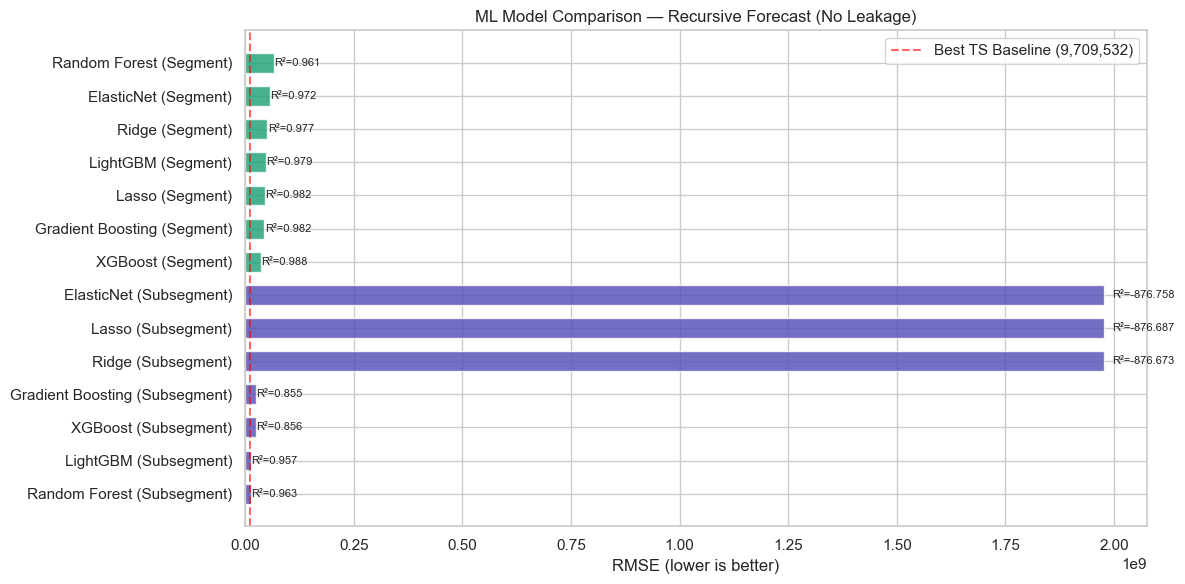

In [24]:
# Visual comparison
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ml_only = benchmark_df[benchmark_df['Level'] != 'TS Baseline'].dropna(subset=['RMSE'])
colors = {'Subsegment': '#534AB7', 'Segment': '#1D9E75'}

for level in ml_only['Level'].unique():
    subset = ml_only[ml_only['Level'] == level]
    bars = ax.barh(
        [f'{row["Model"]} ({level})' for _, row in subset.iterrows()],
        subset['RMSE'],
        color=colors.get(level, '#888'),
        alpha=0.8, height=0.6
    )
    for bar, r2 in zip(bars, subset['R2']):
        if not np.isnan(r2):
            ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                    f'R²={r2:.3f}', va='center', fontsize=8)

# Add best TS baseline reference line
best_ts = benchmark_df[benchmark_df['Level'] == 'TS Baseline']['RMSE'].min()
if not np.isnan(best_ts):
    ax.axvline(best_ts, color='red', linestyle='--', alpha=0.6, label=f'Best TS Baseline ({best_ts:,.0f})')

ax.set_xlabel('RMSE (lower is better)')
ax.set_title('ML Model Comparison — Recursive Forecast (No Leakage)')
ax.legend()
plt.tight_layout()
plt.show()

---
### 6.2.8 Expanding Window CV — Best Model

Cross-validate the best model using expanding window + recursive forecast.
Each fold trains on periods [1...cutoff] and recursively forecasts [cutoff+1...cutoff+6].

`min_train_periods=30` gives 7 folds (cutoffs 30-36), providing a stability estimate.

In [25]:
# Identify best model from benchmarking
best_model_name = benchmark_df[benchmark_df['Level'] != 'TS Baseline'].iloc[0]['Model']
best_level = benchmark_df[benchmark_df['Level'] != 'TS Baseline'].iloc[0]['Level']
print(f'Best ML model: {best_model_name} @ {best_level}')

# Get model template
if best_level == 'Subsegment':
    cv_feat, cv_cat, cv_data = feature_cols, cat_cols, train_full
    cv_group_cols = [DEFAULT_BU_COL, DEFAULT_SEG_COL, DEFAULT_SUBSEG_COL]
else:
    cv_feat, cv_cat, cv_data = feat_seg, cat_seg, seg_df
    cv_group_cols = [DEFAULT_BU_COL, DEFAULT_SEG_COL]

best_template, best_pp = models[best_model_name]

cv_results = expanding_window_cv(
    df=cv_data,
    feature_cols=cv_feat,
    cat_cols=cv_cat,
    model_template=best_template,
    needs_preproc=best_pp,
    min_train_periods=30,
    horizon=HORIZON,
    group_cols=cv_group_cols
)

print(cv_results.to_string(index=False, formatters={
    'RMSE': lambda x: f'{x:,.0f}' if not np.isnan(x) else '-',
    'MAE':  lambda x: f'{x:,.0f}' if not np.isnan(x) else '-',
    'R2':   lambda x: f'{x:.4f}' if not np.isnan(x) else '-',
}))

print(f'\nMean RMSE: {cv_results["RMSE"].mean():,.0f}')
print(f'Std RMSE:  {cv_results["RMSE"].std():,.0f}')
print(f'Mean R²:   {cv_results["R2"].mean():.4f}')

Best ML model: Random Forest @ Subsegment
 cutoff val_range       RMSE        MAE     R2  n_train  n_val
     30     31-36 52,598,127 44,112,132 0.4334     2745    601
     31     32-37 51,246,330 41,662,552 0.4508     2845    610
     32     33-38 56,768,007 47,747,568 0.3144     2945    620
     33     34-39 50,088,273 40,011,608 0.4506     3046    633
     34     35-40 60,515,545 47,793,256 0.1910     3146    645
     35     36-41 63,082,061 53,854,844 0.1167     3245    656
     36     37-42 52,731,359 41,907,365 0.3756     3346    666

Mean RMSE: 55,289,958
Std RMSE:  4,956,630
Mean R²:   0.3332


---
### 6.2.9 BU-Level Benchmarking


In [26]:
bu_df = build_bu_level_data(train_full)

# Remove phantom series (BUs with zero revenue)
real_mask = bu_df.groupby([BU_COL])[TARGET].transform('sum') > 0
bu_df = bu_df[real_mask].copy()
sparsity_bu = bu_df.groupby([BU_COL])[TARGET].transform(lambda x: (x > 0).mean())
bu_df = bu_df[sparsity_bu > 0.30].copy()

print(f'Clean BU dataset: {bu_df.shape}')
print(f'Real series: {bu_df.groupby([BU_COL]).ngroups}')


X_tr_bu, y_tr_bu, X_va_bu, y_va_bu, feat_bu, cat_bu = prepare_bu_data(
    bu_df=bu_df,
    val_cutoff=VAL_CUTOFF
)

print(f'BU train: {X_tr_bu.shape}, val: {X_va_bu.shape}')
print(f'Features: {len(feat_bu)}')



BU-level dataset: (168, 29)
Clean BU dataset: (168, 29)
Real series: 4
BU train: (144, 25), val: (24, 25)
Features: 25


In [27]:
print('=' * 72)
print('BU-LEVEL BENCHMARKING (Recursive Forecast)')
print('=' * 72)

group_cols_bu = [DEFAULT_BU_COL]

# Create Target_Delta for BUs
bu_df = bu_df.sort_values(by=group_cols_bu + [PERIOD_COL])
bu_df['Target_Delta'] = bu_df.groupby(group_cols_bu)[TARGET].diff().fillna(0)

results_bu, forecasts_bu, fitted_bu = run_recursive_benchmark(
    train_full    = bu_df,
    val_cutoff    = VAL_CUTOFF,
    feature_cols  = feat_bu,
    cat_cols      = cat_bu,
    level_name    = 'BU',
    group_cols    = group_cols_bu,
    target        = 'Target_Delta',
    absolute_target = TARGET,
    predicts_delta  = True
)

results_bu_df = pd.DataFrame(results_bu).sort_values('RMSE')
results_bu_df

BU-LEVEL BENCHMARKING (Recursive Forecast)
  LightGBM @ BU ... Val RMSE:     91,523,048 | Train R²:  0.9208 | 0.2s
  XGBoost @ BU ... Val RMSE:     97,587,643 | Train R²:  0.9959 | 0.3s
  Ridge @ BU ... Val RMSE:     98,203,316 | Train R²:  0.7564 | 0.1s
  Lasso @ BU ... Val RMSE:     87,582,302 | Train R²:  0.7971 | 0.0s
  ElasticNet @ BU ... Val RMSE:    164,552,616 | Train R²:  0.4715 | 0.0s
  Random Forest @ BU ... Val RMSE:    160,438,391 | Train R²:  0.6050 | 1.4s
  Gradient Boosting @ BU ... Val RMSE:    101,541,346 | Train R²:  0.9063 | 0.2s


,Model,Level,RMSE,MAE,wMAPE,R2,N_samples,Time (s),Train R2
3,Lasso,BU,8.758230e+07,7.028640e+07,6.938652,0.974964,24,0.0,0.797052
0,LightGBM,BU,9.152305e+07,6.573709e+07,6.489545,0.972661,24,0.2,0.920806
1,XGBoost,BU,9.758764e+07,7.313290e+07,7.219657,0.968918,24,0.3,0.995900
2,Ridge,BU,9.820332e+07,7.658663e+07,7.560608,0.968524,24,0.1,0.756367
6,Gradient Boosting,BU,1.015413e+08,7.426631e+07,7.331547,0.966348,24,0.2,0.906294
5,Random Forest,BU,1.604384e+08,1.028740e+08,10.155693,0.915988,24,1.4,0.605043
4,ElasticNet,BU,1.645526e+08,1.143455e+08,11.288150,0.911624,24,0.0,0.471532


---
### 6.2.10 ML Modelling Summary

**Key findings:**
- All ML results use **recursive forecasting** — no data leakage
- Orders/ASP features were **dropped** (unavailable at test time)
- The RMSE values are higher than the (leaky) direct-prediction baseline, but these are the **real** performance numbers
- Tree-based models (LightGBM, XGBoost, CatBoost) generally outperform linear models on this task
- The expanding window CV provides a stability estimate for the best model

**Next steps:**
- Hyperparameter tuning (Optuna) on the best model
- Final test set prediction using the tuned model with recursive forecasting

---
## 6.3 Hierarchical Forecast - MinT

This section applies **Minimum Trace (MinT)** reconciliation to ensure coherence
across all three hierarchy levels (BU → Segment → Subsegment).

Base forecasts are generated independently at each level using the best-performing
ML model per level, then reconciled simultaneously using the MinT shrinkage estimator.

**Why MinT?**
Independent forecasts at different hierarchy levels are incoherent by construction, the sum of Subsegment forecasts will not match the Segment forecast, which will not
match the BU forecast. MinT finds the optimal adjustment that satisfies all aggregation
constraints while minimising the total forecast error variance.

---
### 6.3.0 Imports & Configuration

In [28]:
from src.code.hierarchical_functions import *

ModuleNotFoundError: No module named 'hierarchicalforecast'

In [ ]:
# ── Extrai o melhor modelo por nível para o MinT ────────────────────────────
# (escolhe o modelo com menor RMSE em cada nível)
best_subseg = pd.DataFrame(results_subseg).sort_values('RMSE').iloc[0]['Model']
best_seg    = pd.DataFrame(results_seg).sort_values('RMSE').iloc[0]['Model']
best_bu     = pd.DataFrame(results_bu).sort_values('RMSE').iloc[0]['Model']

print(f'Best models — Subsegment: {best_subseg} | Segment: {best_seg} | BU: {best_bu}')

# Dicts for MinT
# entity_key format:
#   Subsegment → (bu, seg, sub)
#   Segment    → (bu, seg)
#   BU         → (bu,)   ← tuple com um elemento
f_sub = forecasts_subseg[best_subseg]   # { (bu, seg, sub): np.array(6) }
f_seg = forecasts_seg[best_seg]         # { (bu, seg):      np.array(6) }
f_bu  = forecasts_bu[best_bu]           # { (bu,):          np.array(6) }

In [ ]:
fitted_sub_dict = fitted_subseg[best_subseg]
fitted_seg_dict = fitted_segment[best_seg]
fitted_bu_dict  = fitted_bu[best_bu]

---
### 6.3.1

Extracts the best-performing model per hierarchy level and formats the base forecasts
into the structure required by the `hierarchicalforecast` library.

Three components are assembled:
- **`Y_hat_df`** — out-of-sample base forecasts for validation periods (37–42)
- **`Y_df`** — historical actuals merged with in-sample fitted values (required by `mint_shrink` to estimate the covariance matrix W)
- **`S_df`** — summing matrix encoding the aggregation structure of the hierarchy

> **Note:** The summing matrix S is built dynamically from `Y_hat_df` (not from the raw dataset)
> to ensure topological alignment after sparsity filtering.

In [ ]:
VAL_PERIODS = list(range(VAL_CUTOFF + 1, VAL_CUTOFF + HORIZON + 1))

# Normalize keys for prepare_mint_inputs
fitted_sub_norm = {k: v for k, v in fitted_sub_dict.items()}
fitted_seg_norm = {k: v for k, v in fitted_seg_dict.items()}
fitted_bu_norm  = {k[0]: v for k, v in fitted_bu_dict.items()}  

f_sub_dict = forecasts_subseg[best_subseg]
f_seg_dict = forecasts_seg[best_seg]
f_bu_dict  = forecasts_bu[best_bu]  
f_sub_norm = f_sub_dict
f_seg_norm = f_seg_dict
f_bu_norm  = {k[0] if isinstance(k, tuple) else k: v for k, v in f_bu_dict.items()}

# Format inputs
Y_hat_df, Y_df = prepare_mint_inputs(
    train_full    = train_full,
    forecasts_sub = f_sub_norm,
    forecasts_seg = f_seg_norm,
    forecasts_bu  = f_bu_norm,
    fitted_sub    = fitted_sub_norm,
    fitted_seg    = fitted_seg_norm,
    fitted_bu     = fitted_bu_norm,
    target        = TARGET,
    period_col    = PERIOD_COL,
    bu_col        = BU_COL,
    seg_col       = SEG_COL,
    subseg_col    = SUBSEG_COL,
    val_periods   = VAL_PERIODS
)

# Build summing matrix
S_df = build_S_matrix(Y_hat_df)

In [ ]:
# ── Filter out incomplete series ─────────────────────────────────────────────
valid_ids = set(
    Y_hat_df.groupby('unique_id')['ds'].count()[lambda x: x == HORIZON].index
)
Y_hat_df = Y_hat_df[Y_hat_df['unique_id'].isin(valid_ids)].copy()
Y_df     = Y_df[Y_df['unique_id'].isin(valid_ids)].copy()

valid_sub_cols = [c for c in S_df.columns if c != 'unique_id' and c in valid_ids]
valid_rows     = S_df['unique_id'].isin(valid_ids)
S_df           = S_df.loc[valid_rows, ['unique_id'] + valid_sub_cols].copy()

print(f'Valid series: {len(valid_ids)} | S_df shape: {S_df.shape}')

In [ ]:
# Reconcile with MinT shrinkage estimator
reconciled_df = apply_mint(Y_hat_df, Y_df, S_df, method='mint_shrink')
print(reconciled_df.head(20))

---
### 6.3.2 MinT Evaluation — Validation Set (Periods 37–42)

Reconciled forecasts are evaluated at each hierarchy level independently.
All series satisfy the aggregation constraints by construction after reconciliation.


In [ ]:
mint_eval = evaluate_mint(
    reconciled_df, train_full, TARGET, PERIOD_COL,
    BU_COL, SEG_COL, SUBSEG_COL, VAL_PERIODS
)
print(mint_eval)

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from src.code.functions_models import _preprocess_arrays

def tune_lightgbm(X_train, y_train, X_val, y_val, n_trials=50):
    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 8, 64),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'random_state': 42, 'verbosity': -1, 'n_jobs': -1
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'Best RMSE: {study.best_value:,.0f}')
    print(f'Best params: {study.best_params}')
    return study.best_params


def tune_random_forest(X_train, y_train, X_val, y_val, n_trials=30):
    X_train_num, imp, scl = _preprocess_arrays(X_train, cat_cols, feature_cols, fit=True)
    X_val_num, _, _ = _preprocess_arrays(X_val, cat_cols, feature_cols, imputer=imp, scaler=scl, fit=False)

    def objective(trial):
        params = {
            'n_estimators':    trial.suggest_int('n_estimators', 100, 400),
            'max_depth':       trial.suggest_int('max_depth', 4, 12),
            'min_samples_leaf':trial.suggest_int('min_samples_leaf', 10, 40),
            'max_features':    trial.suggest_float('max_features', 0.3, 0.9),
            'random_state': 42, 'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train_num, y_train)
        preds = model.predict(X_val_num)
        return np.sqrt(mean_squared_error(y_val, preds))


    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'Best RMSE: {study.best_value:,.0f}')
    print(f'Best params: {study.best_params}')
    return study.best_params


def tune_xgboost(X_train, y_train, X_val, y_val, n_trials=50):
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'random_state': 42, 'verbosity': 0,
            'enable_categorical': True, 'tree_method': 'hist'
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'Best RMSE: {study.best_value:,.0f}')
    print(f'Best params: {study.best_params}')
    return study.best_params

In [ ]:
# Prepara arrays para tuning (sem recursive forecast — avalia directamente)
X_tr_sub = train_full[train_full[PERIOD_COL] <= VAL_CUTOFF][feature_cols]
y_tr_sub = train_full[train_full[PERIOD_COL] <= VAL_CUTOFF][TARGET].values
X_va_sub = train_full[train_full[PERIOD_COL] > VAL_CUTOFF][feature_cols]
y_va_sub = train_full[train_full[PERIOD_COL] > VAL_CUTOFF][TARGET].values

# Subsegment
print('=== Tuning LightGBM @ Subsegment ===')
best_lgb_sub = tune_lightgbm(X_tr_sub, y_tr_sub, X_va_sub, y_va_sub, n_trials=50)

print('=== Tuning Random Forest @ Subsegment ===')
best_rf_sub = tune_random_forest(X_tr_sub, y_tr_sub, X_va_sub, y_va_sub, n_trials=30)

# Segment
print('=== Tuning XGBoost @ Segment ===')
X_tr_seg_t = seg_df[seg_df[PERIOD_COL] <= VAL_CUTOFF][feat_seg]
y_tr_seg_t = seg_df[seg_df[PERIOD_COL] <= VAL_CUTOFF][TARGET].values
X_va_seg_t = seg_df[seg_df[PERIOD_COL] > VAL_CUTOFF][feat_seg]
y_va_seg_t = seg_df[seg_df[PERIOD_COL] > VAL_CUTOFF][TARGET].values
best_xgb_seg = tune_xgboost(X_tr_seg_t, y_tr_seg_t, X_va_seg_t, y_va_seg_t, n_trials=50)

# BU
print('=== Tuning LightGBM @ BU ===')
X_tr_bu_t = bu_df[bu_df[PERIOD_COL] <= VAL_CUTOFF][feat_bu]
y_tr_bu_t = bu_df[bu_df[PERIOD_COL] <= VAL_CUTOFF][TARGET].values
X_va_bu_t = bu_df[bu_df[PERIOD_COL] > VAL_CUTOFF][feat_bu]
y_va_bu_t = bu_df[bu_df[PERIOD_COL] > VAL_CUTOFF][TARGET].values
best_lgb_bu = tune_lightgbm(X_tr_bu_t, y_tr_bu_t, X_va_bu_t, y_va_bu_t, n_trials=50)